## 05 - Bivariate Analysis

Bivariate analysis means studying two variables together, to see if and how they're related. Univariate analysis (Notebook 4) told me what each column looks like on its own - this notebook checks whether those columns move together in any meaningful way.

Three combinations are covered:

Numerical vs Numerical
Numerical vs Categorical
Categorical vs Categorical

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("custumer.csv")
df.shape

(5020, 14)

## 1. Numerical vs Numerical
**Step 1 - Concept**

This checks whether two numerical columns move together - as one goes up, does the other tend to go up too, go down, or stay unrelated? This is measured using correlation, a value between -1 and 1. Close to 1 means strong positive relationship, close to -1 means strong negative, close to 0 means no linear relationship.

**Step 2 - Demonstrate the Concept**

**Simple example:** Height and weight - taller people tend to weigh more, so these two are positively correlated.

**Real-world example:** Hours studied vs exam score - generally, more hours studied is linked to a higher score (though not perfectly).

**Business example:** A telecom company checking TenureYears vs TotalCharges would expect a strong positive relationship, since customers who stay longer naturally accumulate higher total billing.

**AI/ML use case:** If two features are very strongly correlated with each other (not just with the target), that's a sign of multicollinearity - keeping both in a linear model can make the model unstable and the coefficients hard to interpret.

**Why it matters:** Knowing which numerical features move together helps decide what to feed into a model, and helps confirm whether the data behaves the way it logically should (a sanity check on the dataset itself).

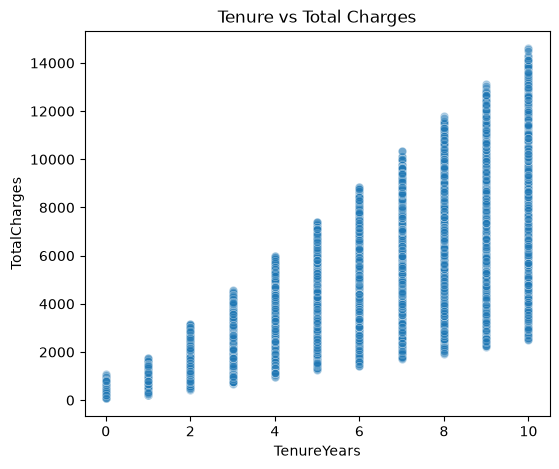

Correlation: 0.784


In [3]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="TenureYears", y="TotalCharges", alpha=0.4)
plt.title("Tenure vs Total Charges")
plt.show()

print("Correlation:", df["TenureYears"].corr(df["TotalCharges"]).round(3))

**Output:** scatter plot showing upward trend. Correlation: 0.784

**Interpretation:** There's a clear upward trend, and the correlation is 0.78 - a strong positive relationship. This makes sense logically: the longer someone has been a customer, the more they've been billed in total.

**Insight:** This is a good sanity check - it confirms TotalCharges behaves the way it should relative to TenureYears, which builds some confidence in the dataset's overall consistency.

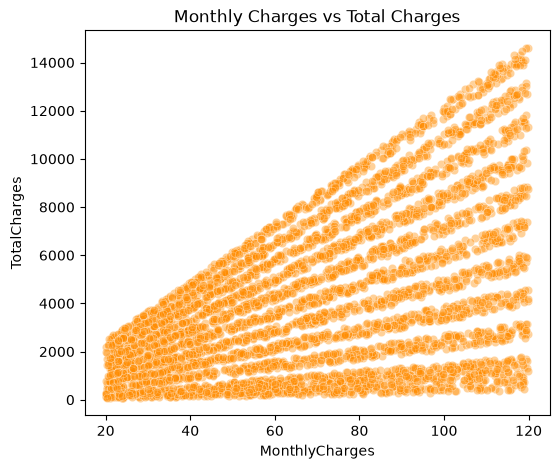

Correlation: 0.519


In [4]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="MonthlyCharges", y="TotalCharges", alpha=0.4, color="darkorange")
plt.title("Monthly Charges vs Total Charges")
plt.show()

print("Correlation:", df["MonthlyCharges"].corr(df["TotalCharges"]).round(3))

**Output:** scatter plot, Correlation: 0.519

**Interpretation:** Moderate positive correlation (0.52) - customers with higher monthly bills tend to have higher total charges too, but it's a looser relationship than with tenure, since total charges depends on both monthly rate and how long someone stays.

**Insight:** Both TenureYears and MonthlyCharges feed into TotalCharges in a fairly direct way. Worth remembering during modeling - using all three together as features could introduce redundancy.

In [6]:
print("Correlation Age vs MonthlyCharges:", df["Age"].corr(df["MonthlyCharges"]).round(3))

Correlation Age vs MonthlyCharges: -0.008


**Interpretation:** Correlation is close to 0 (-0.008) - Age and MonthlyCharges are essentially unrelated in this dataset. Older customers don't pay noticeably more or less than younger ones.

**AI/ML Relevance:** A near-zero correlation like this tells me Age probably won't be a strong linear predictor of billing amount, though it could still matter for the target variable through a different kind of relationship - which is why each pairing needs to be checked on its own instead of assumed.

## 2. Numerical vs Categorical
**Step 1 - Concept**

This checks whether a numerical column behaves differently across the groups of a categorical column - for example, does MonthlyCharges differ by Churn status? This is usually done by comparing group averages and looking at box plots side by side.

**Step 2 - Demonstrate the Concept**

**Simple example:** Comparing average test scores between "Studied" and "Did not study" groups - if studying matters, the averages should be visibly different.

**Real-world example:** Comparing average commute time between people who work from home 3 days a week vs those who commute daily - a real difference here reflects an actual lifestyle impact.

**Business example:** A telecom company comparing MonthlyCharges between customers on Month-to-month vs Two year contracts, to see if pricing differs meaningfully by contract type.

**AI/ML use case:** If TenureYears is clearly lower for customers who churned versus those who didn't, that's a strong signal the model can use - a feature that separates the target classes well is valuable for prediction.

**Why it matters:** This is the first place where I directly connect a feature to the target variable (Churn) - it starts to reveal which features might actually help predict churn, versus which ones don't move the needle.

In [7]:
df.groupby("Churn")[["MonthlyCharges","TenureYears","SupportCalls"]].mean().round(2)

,MonthlyCharges,TenureYears,SupportCalls
Churn,,,
No,69.31,4.96,2.10
Yes,69.90,4.78,2.11


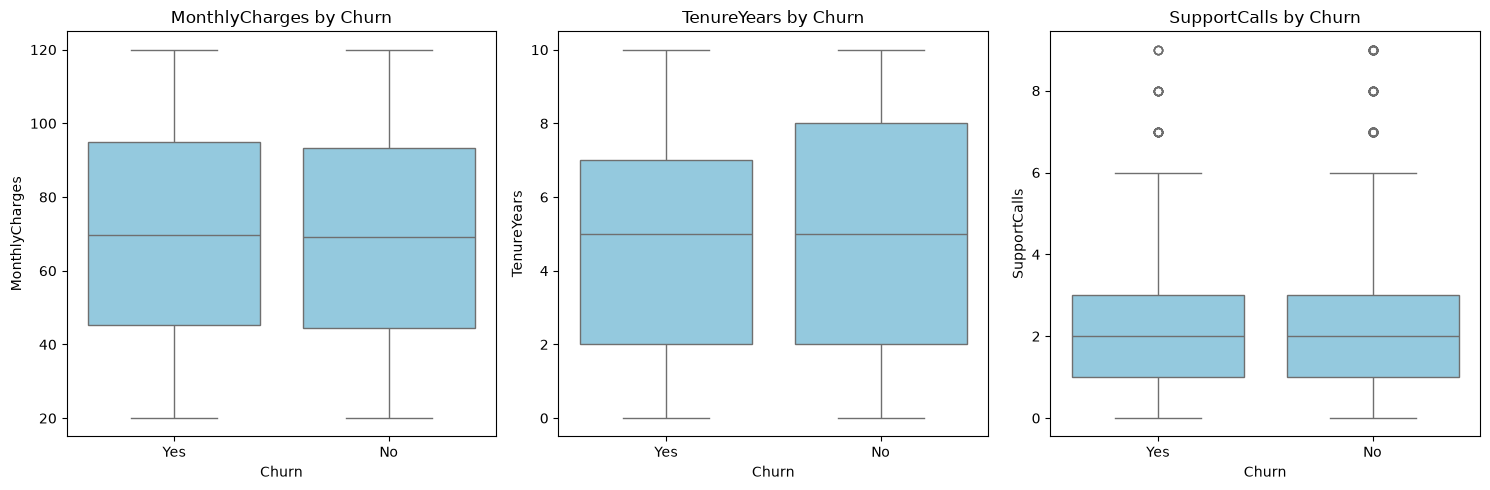

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for i, col in enumerate(["MonthlyCharges","TenureYears","SupportCalls"]):
    sns.boxplot(data=df, x="Churn", y=col, ax=axes[i], color="skyblue")
    axes[i].set_title(f"{col} by Churn")
plt.tight_layout()
plt.show()

**Output:** box plots showing heavy overlap between Churn=Yes and Churn=No groups for all three columns.

**Interpretation:** The average MonthlyCharges, TenureYears, and SupportCalls are almost identical between churned and non-churned customers, and the box plots overlap heavily. There's no visible separation between the two groups on any of these three features.

**Insight:** Based on this dataset alone, these three numerical features don't show a strong individual relationship with churn - none of them look like a strong standalone predictor. That's a real, useful finding, not a failure of the analysis - it means churn in this dataset isn't clearly driven by billing amount, tenure, or support-call frequency on their own.

**AI/ML Relevance:** This doesn't mean these features are useless for a model - a combination of features (multivariate) or an interaction between them might still matter, which is exactly what Notebook 6 (Multivariate Analysis) will check next. It does mean I shouldn't expect any single one of these three to carry the prediction on its own.

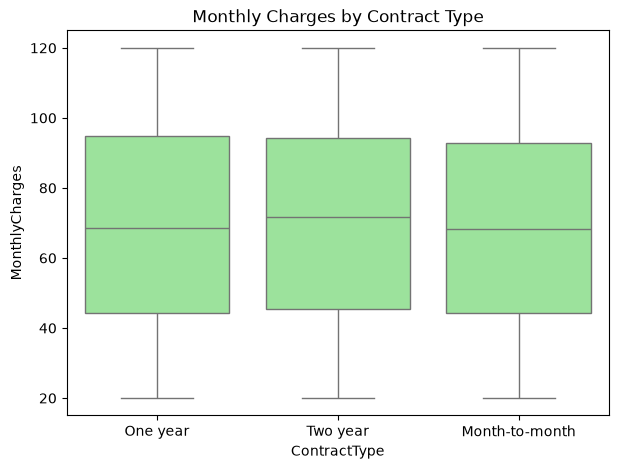

ContractType
Month-to-month    68.92
One year          69.43
Two year          70.31
Name: MonthlyCharges, dtype: float64

In [9]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="ContractType", y="MonthlyCharges", color="lightgreen")
plt.title("Monthly Charges by Contract Type")
plt.show()

df.groupby("ContractType")["MonthlyCharges"].mean().round(2)

**Interpretation:** Average MonthlyCharges is very close across all three contract types (68.9 to 70.3) - contract type doesn't meaningfully change how much a customer pays per month in this dataset.

**Insight:** I expected Two year contracts might come with a pricing incentive, but that's not reflected here - worth noting as a real observation about this dataset rather than assuming it based on general telecom intuition.

## 3. Categorical vs Categorical
**Step 1 - Concept**

This checks whether two categorical columns are related - does the distribution of one category change depending on the other? This is done with cross-tabulation (a table of counts or percentages for each combination), often shown as percentages within each group so groups of different sizes can be compared fairly.

**Step 2 - Demonstrate the Concept**

**Simple example:** Checking if "Pass/Fail" rate differs between "Morning batch" and "Evening batch" students - a cross-tab shows the pass percentage within each batch side by side.

**Real-world example:** Checking if smartphone brand preference differs by age group - a cross-tab of brand vs age-group shows which brand is more popular in which group.

**Business example:** A telecom company checking whether Churn rate differs by InternetService type - if Fiber optic customers churn more than DSL customers, that points to a possible service-quality issue worth investigating.

**AI/ML use case:** If Churn rate is clearly higher for one ContractType than another, that categorical feature becomes a useful predictor - the model can learn "this category tends to churn more" as a pattern.

**Why it matters:** This is the categorical equivalent of the numerical-vs-categorical check above - it tells me which categorical features actually relate to the target, versus which ones don't show any real pattern.

In [11]:
pd.crosstab(df["ContractType"], df["Churn"], normalize="index").round(3) * 100

Churn,No,Yes
ContractType,,
Month-to-month,71.2,28.8
One year,69.0,31.0
Two year,72.3,27.7


In [12]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index").round(3) * 100

Churn,No,Yes
InternetService,,
DSL,70.5,29.5
Fiber optic,72.2,27.8
No,69.7,30.3


In [13]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index").round(3) * 100

Churn,No,Yes
SeniorCitizen,,
No,71.3,28.7
Yes,69.7,30.3


**Interpretation:** Churn rate stays close to the overall 29% average across every category in ContractType (27.7% to 31.0%), InternetService (27.8% to 30.3%), and SeniorCitizen (28.7% to 30.3%). None of these categorical variables show a meaningfully different churn rate for any of their groups.

**Insight:** Just like the numerical features checked earlier, these categorical features don't show a strong individual relationship with churn either. This is a consistent pattern across the whole bivariate analysis - no single feature checked so far separates churners from non-churners on its own.

**AI/ML Relevance:** This is useful to document honestly in the EDA report - it sets the expectation that a model built on this data may need to rely on combinations of features rather than any one strong individual predictor, and it's worth double-checking in Notebook 6 whether any interaction between features reveals something these individual checks missed.